In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
ogrenci_df = pd.read_excel("agsureli.xlsx")
ogrenci_df

,Ogrenci,Sure
0,O001,2
1,O002,5
2,O003,6
3,O004,1
4,O005,2
5,O006,3
6,O007,1
7,O008,7
8,O009,2
9,O010,5


In [3]:
baglantilar_df = pd.read_excel("Agbaglantilar.xlsx")
baglantilar_df

,Ogrenci_1,Ogrenci_2,Ortak_Platformlar,Ortak_Platform_Sayilari,Ortak_Kullanim_Sureleri
0,O001,O002,Trendyol,1,3.5
1,O001,O003,"Trendyol, Hepsiburada, Yemeksepeti / Getir",3,4.0
2,O001,O004,"Trendyol, Hepsiburada, Yemeksepeti / Getir",3,1.5
3,O001,O005,"Trendyol, Hepsiburada",2,2.0
4,O001,O006,"Trendyol, Hepsiburada, Yemeksepeti / Getir",3,2.5
...,...,...,...,...,...
185,O017,O019,"Trendyol, Yemeksepeti / Getir, Sephora / Watso...",3,4.0
186,O017,O020,"Trendyol, Yemeksepeti / Getir",2,3.5
187,O018,O019,"Trendyol, Sephora / Watsons / Gratis",2,3.0
188,O018,O020,Trendyol,1,2.5


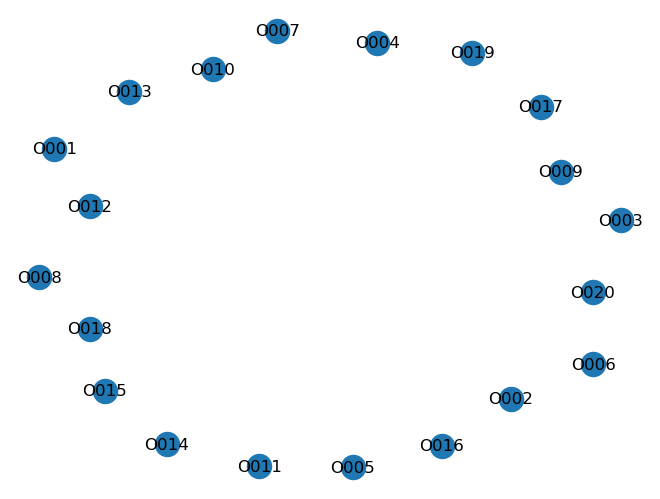

In [4]:
G = nx.Graph()

for i in range(len(ogrenci_df)):
    G.add_node(ogrenci_df["Ogrenci"][i], Sure = ogrenci_df["Sure"][i])
nx.draw(G, with_labels = True)

In [5]:
for i in range(len(baglantilar_df)):
    G.add_edge(baglantilar_df["Ogrenci_1"][i], baglantilar_df["Ogrenci_2"][i],
               ortak_platformlar=baglantilar_df["Ortak_Platformlar"][i],
               ortak_platform_sayisi=baglantilar_df["Ortak_Platform_Sayilari"][i],
               ortalama_sure=baglantilar_df["Ortak_Kullanim_Sureleri"][i])

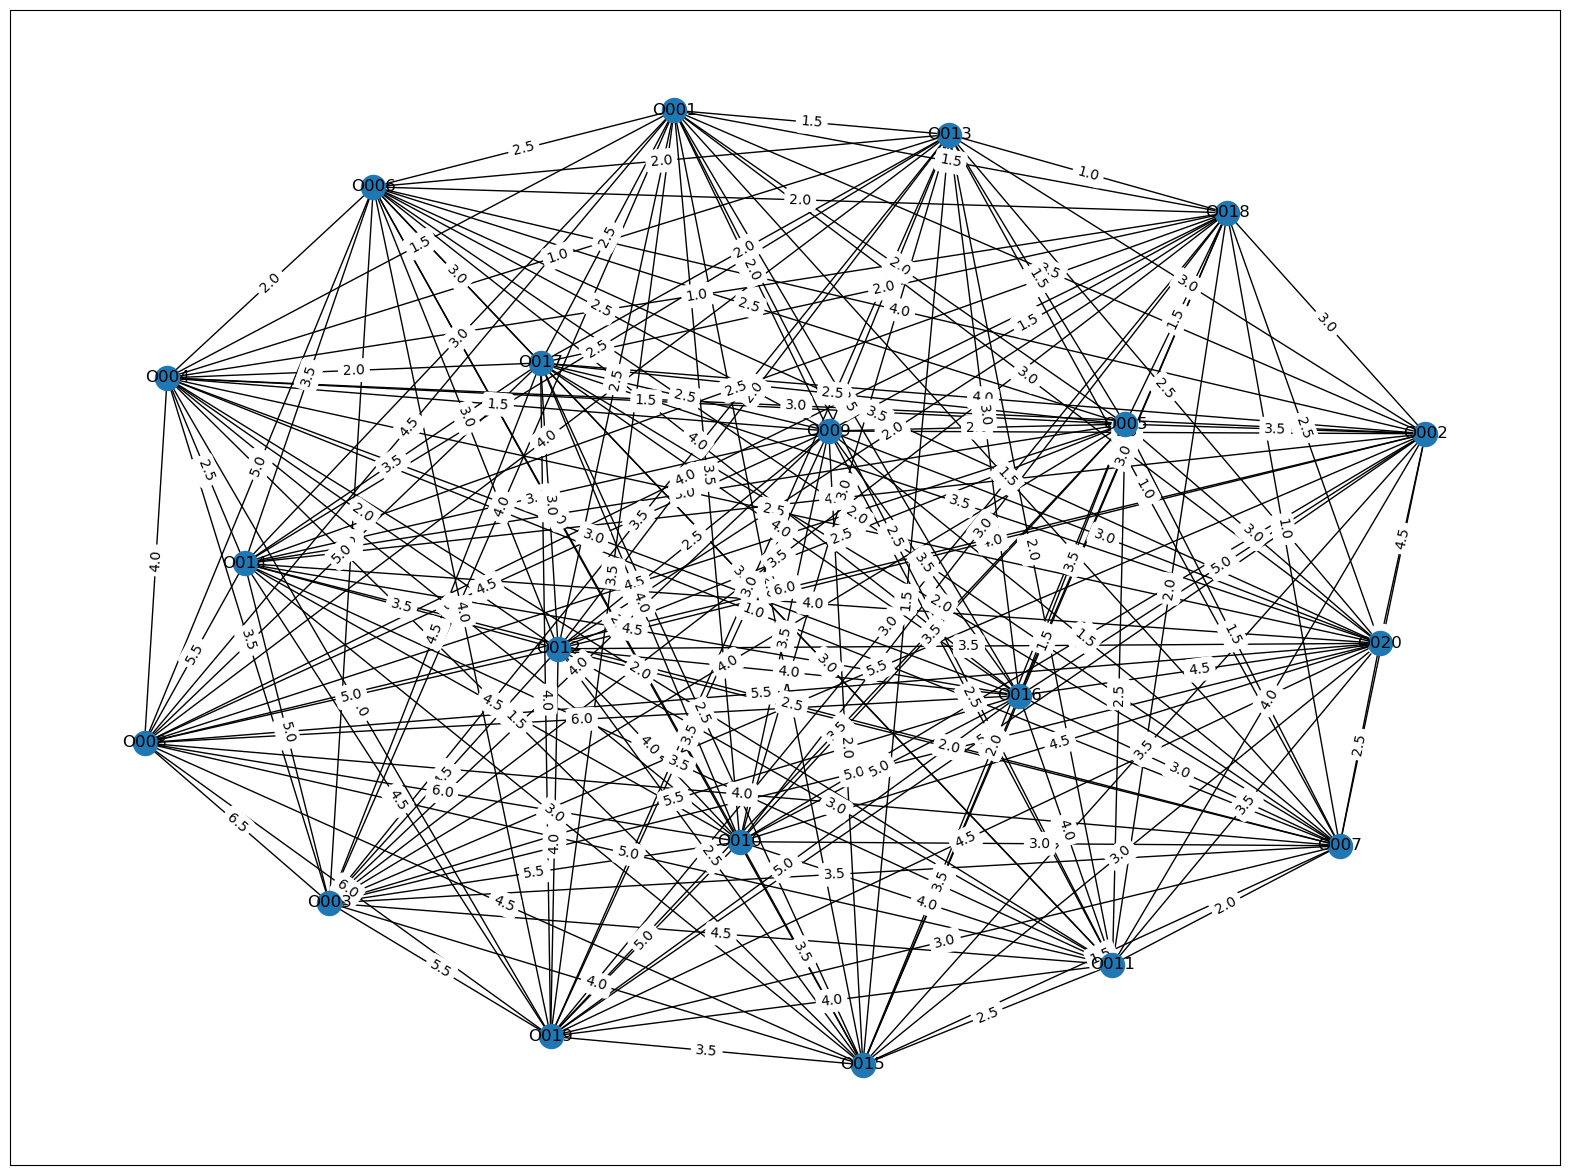

In [6]:
pos = nx.spring_layout(G, k=1, seed=42)
plt.figure(figsize=(20,15))
nx.draw_networkx_nodes(G,pos)
nx.draw_networkx_labels(G,pos)
nx.draw_networkx_edges(G,pos)
ortak_platformlar_sayisi = nx.get_edge_attributes(G, "ortak_platform_sayisi")
ortalama_sure = nx.get_edge_attributes(G, "ortalama_sure")
nx.draw_networkx_edge_labels(G, pos, edge_labels=ortalama_sure)
plt.show()

En düşük ortalama kullanıma sahip 'Güçlü' bağlantı çift(ler)i: [('O004', 'O007'), ('O004', 'O013'), ('O007', 'O013')]
Bu çiftlerin iki öğrenciye ait ortalama kullanım süresi: 1.0



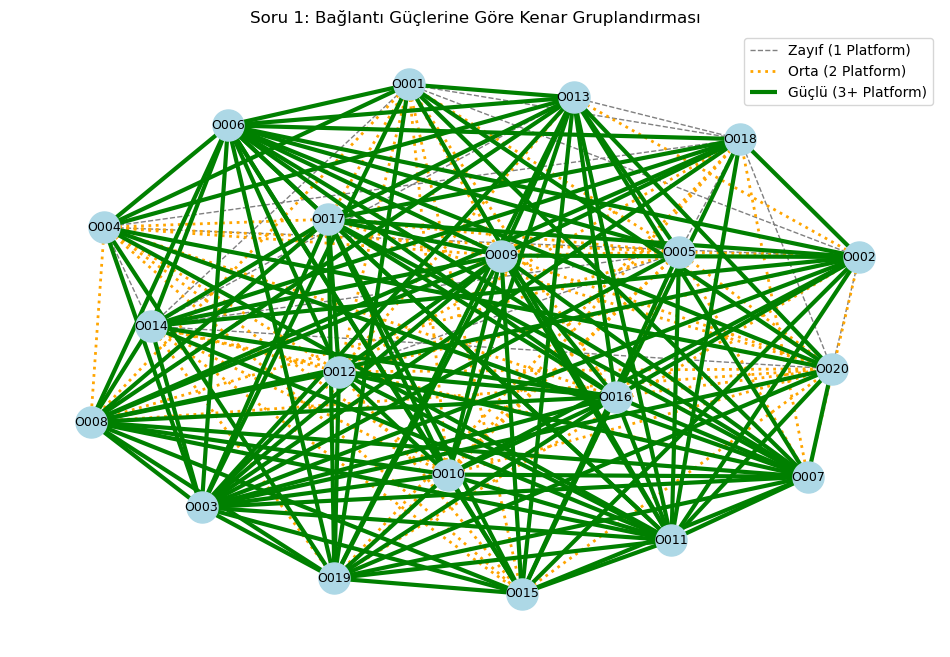

In [7]:
"""
Soru 1: Öğrenciler arasındaki bağlantıları ortak kullandıkları platform sayısına göre zayıf, orta ve güçlü olarak sınıflandırınız. 
En düşük kullanım süresine sahip güçlü bağlantıyı bulunuz.
"""

zayif_kenarlar = []
orta_kenarlar = []
guclu_kenarlar = []

verimsiz_ciftler = []
en_dusuk_ortalama_sure = float('inf')

for ogrenci_1, ogrenci_2, kenar_verisi in G.edges(data=True):
    platform_sayisi = kenar_verisi["ortak_platform_sayisi"]
    ortalama_sure = kenar_verisi["ortalama_sure"] 


    if platform_sayisi == 1:
        zayif_kenarlar.append((ogrenci_1, ogrenci_2))
    elif platform_sayisi == 2:
        orta_kenarlar.append((ogrenci_1, ogrenci_2))
    elif platform_sayisi >= 3:
        guclu_kenarlar.append((ogrenci_1, ogrenci_2))
        
       
        if ortalama_sure < en_dusuk_ortalama_sure:
            en_dusuk_ortalama_sure = ortalama_sure
            verimsiz_ciftler = [(ogrenci_1, ogrenci_2)]
        elif ortalama_sure == en_dusuk_ortalama_sure:
            verimsiz_ciftler.append((ogrenci_1, ogrenci_2))

print(f"En düşük ortalama kullanıma sahip 'Güçlü' bağlantı çift(ler)i: {verimsiz_ciftler}")
print(f"Bu çiftlerin iki öğrenciye ait ortalama kullanım süresi: {en_dusuk_ortalama_sure}\n")

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=1, seed=42)

nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=500)
nx.draw_networkx_labels(G, pos, font_size=9)

nx.draw_networkx_edges(G, pos, edgelist=zayif_kenarlar, edge_color='gray', style='dashed', width=1, label='Zayıf (1 Platform)')
nx.draw_networkx_edges(G, pos, edgelist=orta_kenarlar, edge_color='orange', style='dotted', width=2, label='Orta (2 Platform)')
nx.draw_networkx_edges(G, pos, edgelist=guclu_kenarlar, edge_color='green', style='solid', width=3, label='Güçlü (3+ Platform)')

plt.legend()
plt.title("Soru 1: Bağlantı Güçlerine Göre Kenar Gruplandırması")
plt.axis("off")
plt.show()

In [8]:
"""
Soru 2: En fazla farklı platform kullanan öğrenciyi bulunuz. 
Bu öğrencinin günlük toplam kullanım süresi ne kadardır?
"""


ogrenci_platformlari = {}
for ogrenci in G.nodes():
    ogrenci_platformlari[ogrenci] = []


for ogrenci_1, ogrenci_2, kenar_verisi in G.edges(data=True):
    platform_metni = kenar_verisi["ortak_platformlar"]
    platform_listesi = platform_metni.split(",")
    
   
    for platform in platform_listesi:
        temiz_platform = platform.strip()
        
        
        if temiz_platform not in ogrenci_platformlari[ogrenci_1]:
            ogrenci_platformlari[ogrenci_1].append(temiz_platform)
            
        if temiz_platform not in ogrenci_platformlari[ogrenci_2]:
            ogrenci_platformlari[ogrenci_2].append(temiz_platform)

en_cok_platform_kullanan = None
max_farkli_platform_sayisi = 0


for ogrenci in ogrenci_platformlari:
    toplam_platform = len(ogrenci_platformlari[ogrenci])
    if toplam_platform > max_farkli_platform_sayisi:
        max_farkli_platform_sayisi = toplam_platform
        en_cok_platform_kullanan = ogrenci


kisi_sure = G.nodes[en_cok_platform_kullanan]["Sure"]

print(f"En fazla farklı platform kullanan öğrenci: {en_cok_platform_kullanan} ({max_farkli_platform_sayisi} farklı platform)")
print(f"Bu öğrencinin günlük toplam kullanım süresi: {kisi_sure}")

En fazla farklı platform kullanan öğrenci: O006 (7 farklı platform)
Bu öğrencinin günlük toplam kullanım süresi: 3


In [9]:
"""
Soru 3: Ortak platform başına en fazla kullanım süresine sahip öğrenci çiftini bulunuz.
Bu çift hangi platformları ortak kullanmaktadır?
"""

en_yuksek_oran = -1.0
odakli_ciftler = []
odakli_platformlar = []

for ogrenci_1, ogrenci_2, kenar_verisi in G.edges(data=True):
    ortalama_sure = kenar_verisi["ortalama_sure"]
    platform_sayisi = kenar_verisi["ortak_platform_sayisi"]
    platform_isimleri = kenar_verisi["ortak_platformlar"]
    
    if platform_sayisi > 0:
        mevcut_oran = ortalama_sure / platform_sayisi
        
        if mevcut_oran > en_yuksek_oran:
            en_yuksek_oran = mevcut_oran
            odakli_ciftler = [(ogrenci_1, ogrenci_2)]
            odakli_platformlar = [platform_isimleri]
            
        elif mevcut_oran == en_yuksek_oran:
            odakli_ciftler.append((ogrenci_1, ogrenci_2))
            odakli_platformlar.append(platform_isimleri)


print(f"Platform Başına Düşen En Yüksek Süre Oranı: {en_yuksek_oran:.2f}")


for sira in range(len(odakli_ciftler)):
    ogrenciler = odakli_ciftler[sira]
    platformlar = odakli_platformlar[sira]
    print(f"En Odaklı Öğrenci Çifti: {ogrenciler[0]} ve {ogrenciler[1]}")
    print(f"Paylaştıkları Platformlar: {platformlar}")

Platform Başına Düşen En Yüksek Süre Oranı: 4.50
En Odaklı Öğrenci Çifti: O002 ve O020
Paylaştıkları Platformlar: Trendyol


En Yüksek Etkileşim Yüküne Sahip Platform: Trendyol
Toplam Etkileşim Yükü: 617.5



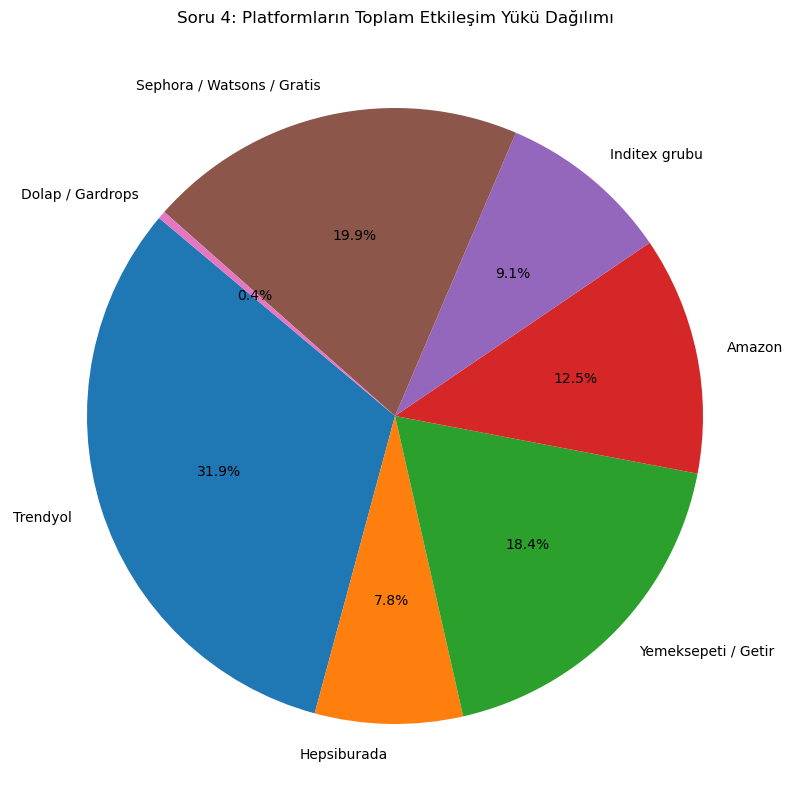

In [10]:
"""
Soru 4: Her platformun ağda yarattığı toplam etkileşim yükünü hesaplayınız. 
Sonuçları pasta grafiği ile görselleştiriniz ve ağda en yüksek etkileşim 
yüküne sahip olan platformu bulunuz.
"""


platform_etkilesim_yuku = {}


for ogrenci_1, ogrenci_2, kenar_verisi in G.edges(data=True):
    platform_metni = kenar_verisi["ortak_platformlar"]
    ortalama_sure = kenar_verisi["ortalama_sure"]
    
    platform_listesi = platform_metni.split(",")
    
    for platform in platform_listesi:
        temiz_platform = platform.strip()
        
        if temiz_platform not in platform_etkilesim_yuku:
            platform_etkilesim_yuku[temiz_platform] = 0.0
            
        platform_etkilesim_yuku[temiz_platform] = platform_etkilesim_yuku[temiz_platform] + ortalama_sure

en_yuksek_platform = None
en_yuksek_yuk = -1.0

for platform in platform_etkilesim_yuku:
    mevcut_yuk = platform_etkilesim_yuku[platform]
    if mevcut_yuk > en_yuksek_yuk:
        en_yuksek_yuk = mevcut_yuk
        en_yuksek_platform = platform

print(f"En Yüksek Etkileşim Yüküne Sahip Platform: {en_yuksek_platform}")
print(f"Toplam Etkileşim Yükü: {en_yuksek_yuk}\n")

platform_isimleri = list(platform_etkilesim_yuku.keys())
etkilesim_yukleri = list(platform_etkilesim_yuku.values())

plt.figure(figsize=(10, 10))
plt.pie(etkilesim_yukleri, labels=platform_isimleri, autopct='%1.1f%%', startangle=140)
plt.title("Soru 4: Platformların Toplam Etkileşim Yükü Dağılımı")
plt.show()

Öğrenci: O001 -> Komşularıyla Süre Farkı: 1.32
Öğrenci: O002 -> Komşularıyla Süre Farkı: 1.84
Öğrenci: O003 -> Komşularıyla Süre Farkı: 2.89
Öğrenci: O004 -> Komşularıyla Süre Farkı: 2.37
Öğrenci: O005 -> Komşularıyla Süre Farkı: 1.32
Öğrenci: O006 -> Komşularıyla Süre Farkı: 0.26
Öğrenci: O007 -> Komşularıyla Süre Farkı: 2.37
Öğrenci: O008 -> Komşularıyla Süre Farkı: 3.95
Öğrenci: O009 -> Komşularıyla Süre Farkı: 1.32
Öğrenci: O010 -> Komşularıyla Süre Farkı: 1.84
Öğrenci: O011 -> Komşularıyla Süre Farkı: 0.26
Öğrenci: O012 -> Komşularıyla Süre Farkı: 0.26
Öğrenci: O013 -> Komşularıyla Süre Farkı: 2.37
Öğrenci: O014 -> Komşularıyla Süre Farkı: 0.79
Öğrenci: O015 -> Komşularıyla Süre Farkı: 1.32
Öğrenci: O016 -> Komşularıyla Süre Farkı: 1.84
Öğrenci: O017 -> Komşularıyla Süre Farkı: 0.26
Öğrenci: O018 -> Komşularıyla Süre Farkı: 2.37
Öğrenci: O019 -> Komşularıyla Süre Farkı: 1.84
Öğrenci: O020 -> Komşularıyla Süre Farkı: 0.79

Çevresiyle arasındaki süre uçurumu en yüksek olan öğrenci: 

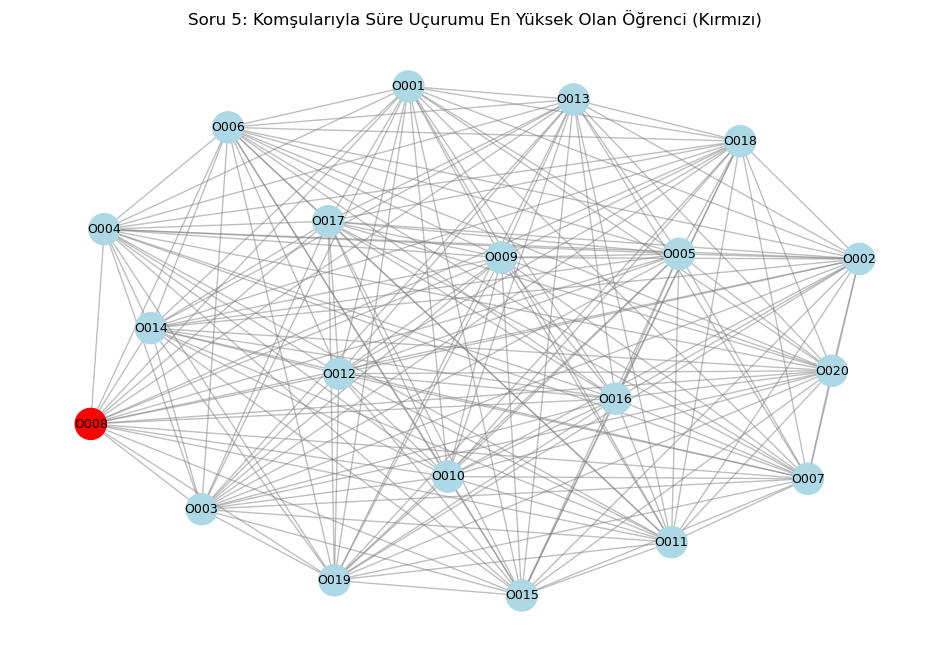

In [11]:
"""
Soru 5:Kendi kullanım süresi ile komşularının ortalama kullanım süresi arasında
en büyük fark olan öğrenciyi bulunuzve ağ üzerinde gösteriniz.
Ayrıca ağdaki tüm öğrencilerin hesaplanan süre farklarını listeleyiniz.
"""

ogrenci_farklari = {}
en_yuksek_fark = -1.0
ucurum_ogrencisi = None

for ogrenci in G.nodes():
    kendi_suresi = G.nodes[ogrenci]["Sure"]
    komsular = list(G.neighbors(ogrenci))
    
    if len(komsular) > 0:
        komsu_sureleri_toplami = 0.0
        for komsu in komsular:
            komsu_sureleri_toplami = komsu_sureleri_toplami + G.nodes[komsu]["Sure"]
            
        komsu_ortalamasi = komsu_sureleri_toplami / len(komsular)
        mevcut_fark = abs(kendi_suresi - komsu_ortalamasi)
        
        ogrenci_farklari[ogrenci] = mevcut_fark
        print(f"Öğrenci: {ogrenci} -> Komşularıyla Süre Farkı: {mevcut_fark:.2f}")
        
        if mevcut_fark > en_yuksek_fark:
            en_yuksek_fark = mevcut_fark
            ucurum_ogrencisi = ogrenci

print(f"\nÇevresiyle arasındaki süre uçurumu en yüksek olan öğrenci: {ucurum_ogrencisi}")
print(f"En yüksek mutlak fark değeri: {en_yuksek_fark:.2f}\n")

dugum_renkleri = []
for ogrenci in G.nodes():
    if ogrenci == ucurum_ogrencisi:
        dugum_renkleri.append("red")  
    else:
        dugum_renkleri.append("lightblue")  

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=1, seed=42)

nx.draw_networkx_nodes(G, pos, node_color=dugum_renkleri, node_size=500)
nx.draw_networkx_labels(G, pos, font_size=9)
nx.draw_networkx_edges(G, pos, edge_color="gray", alpha=0.5)

plt.title("Soru 5: Komşularıyla Süre Uçurumu En Yüksek Olan Öğrenci (Kırmızı)")
plt.axis("off")
plt.show()

In [12]:
"""
Soru 6: Ağdaki tüm bağlantılar (öğrenci çiftleri) incelendiğinde, ortak platformlarda iki öğrencinin 
birlikte harcadığı ortalama kullanım süresi en yüksek olan en yoğun öğrenci çiftini ve bu süreyi bulunuz.
"""

en_yuksek_ortalama_sure = -1.0
en_yogun_ciftler = []

for ogrenci_1, ogrenci_2, kenar_verisi in G.edges(data=True):
    ortalama_sure = kenar_verisi["ortalama_sure"]
    
    if ortalama_sure > en_yuksek_ortalama_sure:
        en_yuksek_ortalama_sure = ortalama_sure
        en_yogun_ciftler = [(ogrenci_1, ogrenci_2)]
        
    elif ortalama_sure == en_yuksek_ortalama_sure:
        en_yogun_ciftler.append((ogrenci_1, ogrenci_2))

print(f"En Fazla Ortalama Zaman Harcayan Öğrenci Çift(ler)i:")
for cift in en_yogun_ciftler:
    print(f"- {cift[0]} ve {cift[1]}")

print(f"Harcanan En Yüksek Ortalama Süre: {en_yuksek_ortalama_sure}")

En Fazla Ortalama Zaman Harcayan Öğrenci Çift(ler)i:
- O003 ve O008
Harcanan En Yüksek Ortalama Süre: 6.5


In [13]:
"""
Soru 7: En fazla çeşitte farklı platform  kullanan öğrenci veya öğrencileri bulunuz.
Ayrıca tüm öğrencilerin kullandığı toplam farklı platform listesini ve platform sayılarını ekrana yazdırınız.
"""

ogrenci_platformlari = {}
for ogrenci in G.nodes():
    ogrenci_platformlari[ogrenci] = []

for ogrenci_1, ogrenci_2, kenar_verisi in G.edges(data=True):
    platform_metni = kenar_verisi["ortak_platformlar"]
    platform_listesi = platform_metni.split(",")
    
    for platform in platform_listesi:
        temiz_platform = platform.strip()
        
        if temiz_platform not in ogrenci_platformlari[ogrenci_1]:
            ogrenci_platformlari[ogrenci_1].append(temiz_platform)
            
        if temiz_platform not in ogrenci_platformlari[ogrenci_2]:
            ogrenci_platformlari[ogrenci_2].append(temiz_platform)

print("--- TÜM ÖĞRENCİLERİN KULLANDIĞI PLATFORMLAR ---")
for ogrenci in ogrenci_platformlari:
    liste = ogrenci_platformlari[ogrenci]
    sayi = len(liste)
    print(f"Öğrenci {ogrenci}: (Toplam {sayi} Platform) -> {liste}")

max_farkli_platform_sayisi = 0
en_cok_platform_kullananlar = []

for ogrenci in ogrenci_platformlari:
    toplam_platform = len(ogrenci_platformlari[ogrenci])
    if toplam_platform > max_farkli_platform_sayisi:
        max_farkli_platform_sayisi = toplam_platform

for ogrenci in ogrenci_platformlari:
    if len(ogrenci_platformlari[ogrenci]) == max_farkli_platform_sayisi:
        en_cok_platform_kullananlar.append(ogrenci)

print("\n--- EN FAZLA FARKLI PLATFORM KULLANAN ÖĞRENCİLER ---")
print(f"En Fazla Çeşit Platform Sayısı: {max_farkli_platform_sayisi}")
print(f"Bu Sayıya Ulaşan Öğrenci(ler): {en_cok_platform_kullananlar}")

--- TÜM ÖĞRENCİLERİN KULLANDIĞI PLATFORMLAR ---
Öğrenci O001: (Toplam 3 Platform) -> ['Trendyol', 'Hepsiburada', 'Yemeksepeti / Getir']
Öğrenci O002: (Toplam 4 Platform) -> ['Trendyol', 'Amazon', 'Inditex grubu', 'Sephora / Watsons / Gratis']
Öğrenci O003: (Toplam 6 Platform) -> ['Trendyol', 'Hepsiburada', 'Yemeksepeti / Getir', 'Amazon', 'Inditex grubu', 'Sephora / Watsons / Gratis']
Öğrenci O004: (Toplam 3 Platform) -> ['Trendyol', 'Hepsiburada', 'Yemeksepeti / Getir']
Öğrenci O005: (Toplam 4 Platform) -> ['Trendyol', 'Hepsiburada', 'Amazon', 'Dolap / Gardrops']
Öğrenci O006: (Toplam 7 Platform) -> ['Trendyol', 'Hepsiburada', 'Yemeksepeti / Getir', 'Amazon', 'Inditex grubu', 'Sephora / Watsons / Gratis', 'Dolap / Gardrops']
Öğrenci O007: (Toplam 4 Platform) -> ['Trendyol', 'Hepsiburada', 'Yemeksepeti / Getir', 'Sephora / Watsons / Gratis']
Öğrenci O008: (Toplam 5 Platform) -> ['Trendyol', 'Yemeksepeti / Getir', 'Amazon', 'Inditex grubu', 'Sephora / Watsons / Gratis']
Öğrenci O009: (T

In [14]:
"""
Soru 8: Öğrenci çiftlerinin ortak kullandığı platformlar incelendiğinde; "Amazon" kullanan bağlantılar 
ile "Hepsiburada" kullanan bağlantıları karşılaştırıp, bağlantı başına düşen kullanım süresini hesaplayarak 
hangisinin kullanıcıları daha uzun süre ağda tuttuğunu bulma.
"""

amazon_sure_toplam = 0.0
amazon_baglanti_sayisi = 0

hepsi_sure_toplam = 0.0
hepsi_baglanti_sayisi = 0

for ogrenci_1, ogrenci_2, kenar_verisi in G.edges(data=True):
    platformlar_metni = kenar_verisi["ortak_platformlar"]
    ortalama_sure = kenar_verisi["ortalama_sure"]
    
    if "Amazon" in platformlar_metni:
        amazon_sure_toplam = amazon_sure_toplam + ortalama_sure
        amazon_baglanti_sayisi = amazon_baglanti_sayisi + 1
        
    if "Hepsiburada" in platformlar_metni:
        hepsi_sure_toplam = hepsi_sure_toplam + ortalama_sure
        hepsi_baglanti_sayisi = hepsi_baglanti_sayisi + 1

amazon_ortalama = 0.0
if amazon_baglanti_sayisi > 0:
    amazon_ortalama = amazon_sure_toplam / amazon_baglanti_sayisi

hepsi_ortalama = 0.0
if hepsi_baglanti_sayisi > 0:
    hepsi_ortalama = hepsi_sure_toplam / hepsi_baglanti_sayisi

print(f"Amazon Geçen Toplam Bağlantı Sayısı: {amazon_baglanti_sayisi}")
print(f"Amazon Bağlantı Başına Düşen Kullanım Süresi: {amazon_ortalama:.2f}")
print("-" * 40)
print(f"Hepsiburada Geçen Toplam Bağlantı Sayısı: {hepsi_baglanti_sayisi}")
print(f"Hepsiburada Bağlantı Başına Düşen Kullanım Süresi: {hepsi_ortalama:.2f}")
print("-" * 40)

if amazon_ortalama > hepsi_ortalama:
    print("Sonuç: Amazon içeren bağlantıların ortalama süresi daha yüksek olduğundan, Amazon kullanıcıları ağda daha uzun süre tutmaktadır.")
elif hepsi_ortalama > amazon_ortalama:
    print("Sonuç: Hepsiburada içeren bağlantıların ortalama süresi daha yüksek olduğundan, Hepsiburada kullanıcıları ağda daha uzun süre tutmaktadır.")
else:
    print("Sonuç: Her iki platformun da bağlantı başına düşen kullanım süreleri birbirine eşittir.")

Amazon Geçen Toplam Bağlantı Sayısı: 66
Amazon Bağlantı Başına Düşen Kullanım Süresi: 3.67
----------------------------------------
Hepsiburada Geçen Toplam Bağlantı Sayısı: 55
Hepsiburada Bağlantı Başına Düşen Kullanım Süresi: 2.73
----------------------------------------
Sonuç: Amazon içeren bağlantıların ortalama süresi daha yüksek olduğundan, Amazon kullanıcıları ağda daha uzun süre tutmaktadır.
